### Step 1: Import necessary libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE
import joblib 
import os

### Step 2: Load the data

In [25]:
#Loading dataset
df = pd.read_csv('../data/creditcard.csv')

# Display first few rows of the dataset
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Step 3: Exploratory Data Analysis (EDA) 

In [26]:
#3.1 Basic info about the dataset
print("\nDataset Info:")
df.info()

print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64



Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


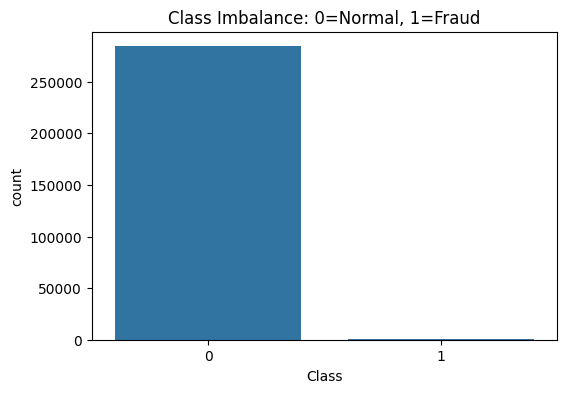

In [27]:
#3.2 Class distribution
class_counts = df['Class'].value_counts()
print("\nClass Distribution:")
print(class_counts)

#Visualize class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Class Imbalance: 0=Normal, 1=Fraud')
plt.savefig('../images/class_imbalance.png')
plt.show()

### Step 4: Prepare features (X) and target (y)

In [28]:
X = df.drop('Class', axis=1)
y = df['Class']

### Step 5: split the data into training and testing sets

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Step 6: Scale features

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Save the scaler (so we can preprocess new data later)
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']

### Step 7: Apply SMOTE

In [31]:
print("Applying SMOTE to balance training data...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE - Fraud:", sum(y_train), "Normal:", len(y_train) - sum(y_train))
print("After SMOTE - Fraud:", sum(y_train_smote), "Normal:", len(y_train_smote) - sum(y_train_smote))

Applying SMOTE to balance training data...
Before SMOTE - Fraud: 394 Normal: 227451
After SMOTE - Fraud: 227451 Normal: 227451


### Step 8: Visualize SMOTE

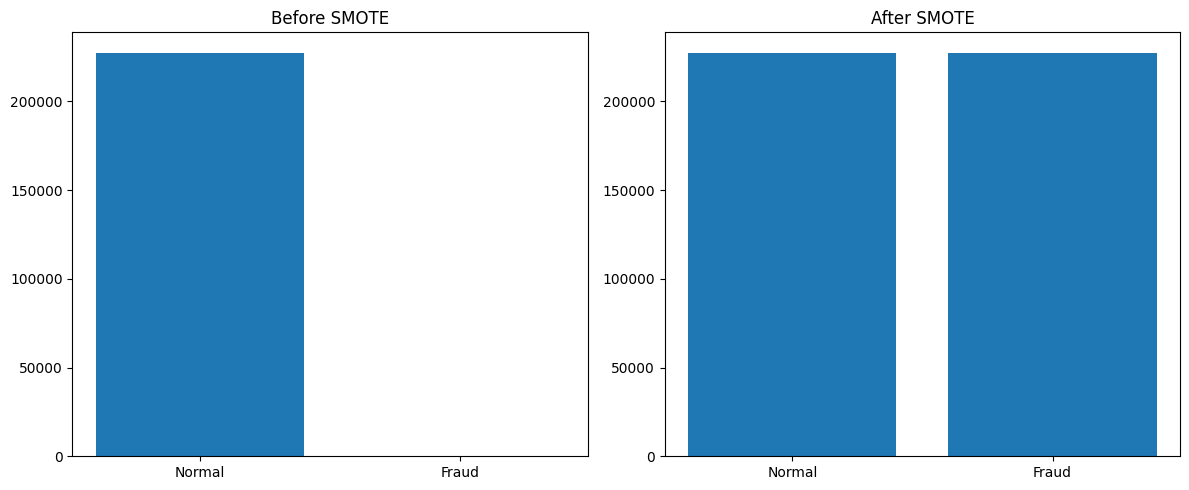

In [32]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(['Normal', 'Fraud'], [len(y_train) - sum(y_train), sum(y_train)])
plt.title('Before SMOTE')
plt.subplot(1, 2, 2)
plt.bar(['Normal', 'Fraud'], [len(y_train_smote) - sum(y_train_smote), sum(y_train_smote)])
plt.title('After SMOTE')
plt.tight_layout()
plt.savefig('../images/sMOTE_comparison.png')
plt.show()

### Step 9: Train 3 models


Training Logistic Regression...
Logistic Regression Results:
  Accuracy:  0.974
  Precision: 0.058
  Recall:    0.918
  F1-Score:  0.109


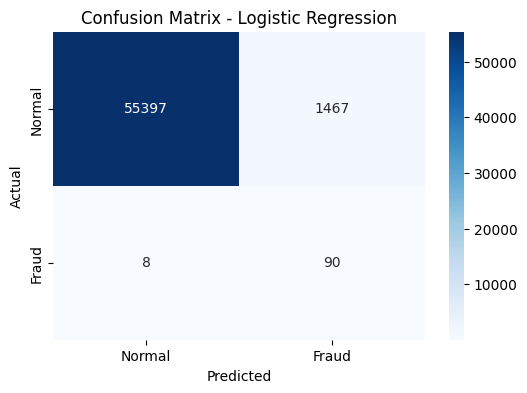


Training Random Forest...
Random Forest Results:
  Accuracy:  0.999
  Precision: 0.871
  Recall:    0.827
  F1-Score:  0.848


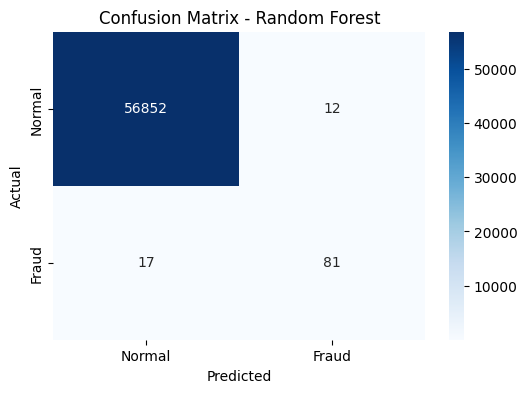


Training XGBoost...


d:\Download\DS\my_project\credit-card-fraud-detection\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:55:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results:
  Accuracy:  0.999
  Precision: 0.728
  Recall:    0.847
  F1-Score:  0.783


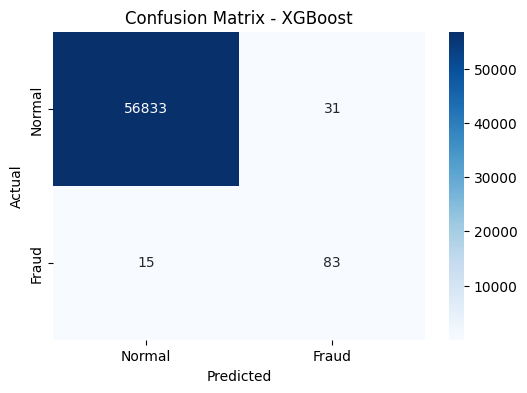

In [33]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}
trained_models = {}  # Store trained models

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }
    trained_models[name] = model  # Save trained model in memory
    
    print(f"{name} Results:")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1-Score:  {f1:.3f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig(f'../images/cm_{name.replace(" ", "_")}.png')
    plt.show()

### Step 11: Find and the BEST model (by F1-Score)


Final Results Comparison:
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.974106   0.057803  0.918367  0.108761
Random Forest        0.999491   0.870968  0.826531  0.848168
XGBoost              0.999192   0.728070  0.846939  0.783019


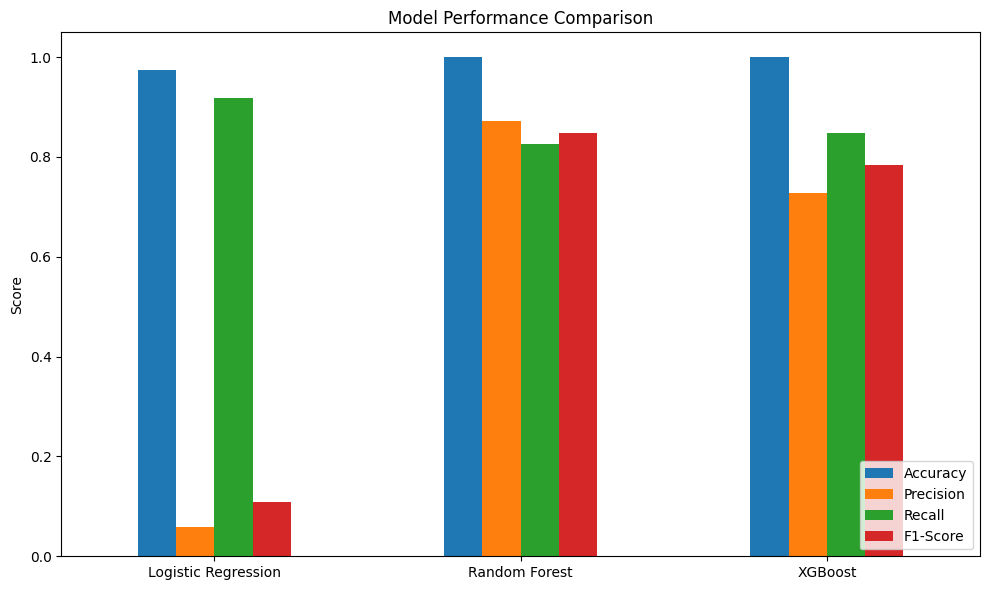


Best Model: Random Forest (F1-Score: 0.8482)
Best model saved to: ../models/best_model_Random_Forest.pkl


In [34]:
results_df = pd.DataFrame(results).T
print("\nFinal Results Comparison:")
print(results_df)

# Plot comparison
results_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../images/model_comparison.png')
plt.show()


# Find best model
best_model_name = results_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]

print(f"\nBest Model: {best_model_name} (F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f})")

# Save the best model
model_path = f'../models/best_model_{best_model_name.replace(" ", "_")}.pkl'
joblib.dump(best_model, model_path)
print(f"Best model saved to: {model_path}")

